# DDPM on MNIST

Here, we want to implement and train a simple diffusion model on the MNIST data set, which learns to generate images of handwritten digits.

### Imports, loading the data and fundamental classes


In [5]:
import os
import pathlib
from argparse import ArgumentParser
import pytorch_lightning as pl

In [6]:
!pip install torch_lr_finder;
from torch_lr_finder import LRFinder

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
from tqdm.notebook import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader

batch_size = 32

In [8]:
import wandb
from pytorch_lightning.loggers import WandbLogger


In [9]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
import os
os.chdir('/content/drive/MyDrive/MLPA Project')


In [11]:
os.listdir('.')


['unet_mod.py',
 '__pycache__',
 'data',
 'mnist_unet.pkl',
 'wandb',
 'mnist-diffusion',
 'mnist_diffusion_part3.ipynb']

In [12]:
import sys
sys.path.append('.')

from unet_mod import Unet

In [46]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)
pl.seed_everything(42, workers=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

This class sets the noise schedule beta_t

In [13]:
class NoiseScheduler(nn.Module):
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        # register as buffers — not parameters, but move with .to(device)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.T = T

    def _reshape(self, x, t):
        return x.reshape(-1, 1, 1, 1) if isinstance(t, (torch.Tensor, np.ndarray)) else x

    def beta(self, t): return self._reshape(self.betas[t], t)
    def alpha(self, t): return self._reshape(self.alphas[t], t)
    def alpha_bar(self, t): return self._reshape(self.alpha_bars[t], t)

    def add_noise(self, x, t):
        noise = torch.randn_like(x)
        ab = self.alpha_bar(t)
        return torch.sqrt(ab) * x + torch.sqrt(1 - ab) * noise, noise


scheduler = NoiseScheduler(T=1000)

NoisyMNIST is the data set on which the MNIST is trained: noisy image -> noise pattern

In [14]:
# cell written by Claude
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, scheduler):
        self.dataset = dataset
        self.scheduler = scheduler

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # the device on which the scheduler lies
        scheduler_device = self.scheduler.betas.device
        # the second entry (the number) is being ignored
        x, _ = self.dataset[idx]
        t = torch.randint(0, self.scheduler.T, (1,))
        x_noisy, noise = self.scheduler.add_noise(x.unsqueeze(0).to(scheduler_device), t.to(
            scheduler_device))  # TODO: maybe i rather send the scheduler to the device of the dataset
        return x_noisy.squeeze(0), noise.squeeze(0)


here, we filter only the zeros out the data and actually load the data

In [15]:
# cell generated by Claude
from torch.utils.data import Subset


def zeros_only(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    return Subset(dataset, indices)

from torchvision import datasets, transforms

def load_mnist(transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    train_set = datasets.MNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set = datasets.MNIST(
        root='./data', train=False, download=True, transform=transform)
    return train_set, test_set


def get_zeros_loaders(train_set, test_set, scheduler, batch_size=32):
    train_zeros = NoisyMNIST(zeros_only(train_set), scheduler)
    test_zeros = NoisyMNIST(zeros_only(test_set), scheduler)
    train_loader = DataLoader(train_zeros, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_zeros,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [16]:
train_set, test_set = load_mnist()
train_loader, test_loader = get_zeros_loaders(
    train_set, test_set, scheduler, batch_size=32)

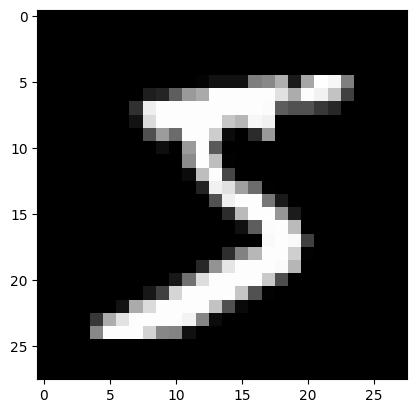

In [17]:
plt.imshow(train_set[0][0].squeeze(), cmap="gray")

### training the model


For speeding up, i use autocast and GradScaler, which, where it is possible, scales numbers to half precision (16 bit), which on gpus allows for significant improvements in speed. GradScaler and autocast deal with issues that can arise here when we just use .half().


In [19]:
def find_lr(model, train_loader, start_lr=1e-7, end_lr=1, num_iter=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    lr_finder = LRFinder(model, optimizer, F.mse_loss)
    lr_finder.range_test(train_loader, end_lr=end_lr, num_iter=num_iter)
    lr_finder.plot()
    lr_finder.reset()
    return lr_finder

In [20]:
def train(model, train_loader, test_loader, epochs=100, lr=1e-2, plot_loss=True,
          early_stopping_patience=10, save_path='model.pkl'):


    wandb.watch(model, log="all", log_freq=100)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6)

    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []

    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in tqdm(range(epochs), desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader, leave=False, desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader, leave=False, desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
            test_loss = epoch_test_loss / len(test_loader)
            lr_scheduler.step(test_loss)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

        # early stopping
        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best model
    model.load_state_dict(torch.load(save_path))

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

In [21]:
class DiffusionUNetModule(pl.LightningModule):
    def __init__(self, model, lr=1e-3):
        super().__init__()
        self.model = model
        self.lr = lr
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x_noisy, noise = batch
        noise_pred = self(x_noisy)
        loss = self.loss_fn(noise_pred, noise)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x_noisy, noise = batch
        noise_pred = self(x_noisy)
        loss = self.loss_fn(noise_pred, noise)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=3, factor=0.5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


In [22]:
class MNISTDiffusionDataModule(pl.LightningDataModule):
    def __init__(self, train_set, test_set, scheduler, batch_size=32):
        super().__init__()
        self.train_set = NoisyMNIST(zeros_only(train_set), scheduler)
        self.test_set = NoisyMNIST(zeros_only(test_set), scheduler)
        self.batch_size = batch_size

    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size)


In [83]:
def run_training():
    set_seed(42)
    pl.seed_everything(42)
    # wandb logger
    logger = WandbLogger(project="mnist-diffusion", name="unet-run")

    # data
    train_set, test_set = load_mnist()
    data_module = MNISTDiffusionDataModule(train_set, test_set, scheduler, batch_size=32)

    # model
    unet = Unet(in_chans=1, out_chans=1, chans=32, num_pool_layers=3)
    model = DiffusionUNetModule(unet, lr=1e-3)

    # trainer
    trainer = pl.Trainer(
        precision="16-mixed",
        max_epochs=20,
        logger=logger,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        deterministic=True,
    )

    trainer.fit(model, datamodule=data_module)
    wandb.finish()


In [76]:
if __name__ == "__main__":
    run_training()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Unet    │  1.9 M │ train │     0 │
│ 1 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 92                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▆▆▆▆▇▇▇▇▇█████
train_loss,█▅▅▄▃▃▄▂▁▇▂▇▆▂▂▄▃▃▂▄▃▃▂▃▂▁▁▁▃▅▂▂▂▃▁▃▂▂▂▃
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
val_loss,█▆▅▄▃▃▃▃▂▂▂▂▂▁▁▁▂▂▁▁
epoch,19
train_loss,0.0364
trainer/global_step,3719
val_loss,0.03494


In [66]:
set_seed(42)
model = Unet(
    in_chans=1,
    out_chans=1,
    chans=32,
    num_pool_layers=3,
    drop_prob=0.0,
    dual_frame=False
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

### Generating an image


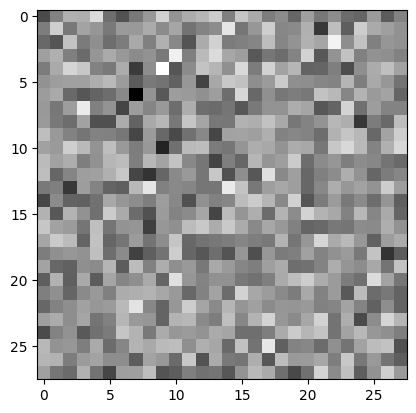

In [77]:
example_image = train_set[0][0].squeeze()


def noisy_image(n=1):
    """generates a batch of n noisy images. Output shape: (nx28x28)"""
    return torch.randn((n, 1, *example_image.shape))


plt.imshow(noisy_image().squeeze(), cmap="gray")
plt.show()

In [78]:
def generate_image(unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=False,seed=42):
    intermediates = []
    x = noisy_image(n_images).to(device)
    if return_intermediates:
        intermediates.append(x)
    for t in range(scheduler.T-1, 0, -1):
        z = noisy_image(n_images).to(device) if t > 1 else torch.zeros_like(x)
        alpha = scheduler.alpha(t)
        alpha_bar = scheduler.alpha_bar(t)
        # sigma_t is here for this simple case set to sqrt(beta), like in the original ho et al paper
        sigma_t = stochasticity*torch.sqrt(scheduler.beta(t))

        noise_pred = unet(x)
        x = 1/torch.sqrt(alpha) * (x - (1-alpha) /
                                   torch.sqrt(1-alpha_bar)*noise_pred) + sigma_t*z

        # print(t, alpha_bar.item(), (1-alpha_bar).item())

        if return_intermediates:
            intermediates.append(x)

    if return_intermediates:
        return x, intermediates

    return x

In [69]:
def plot_image(image):
    plt.imshow(image.cpu().detach().squeeze(), cmap="gray")
    plt.colorbar()

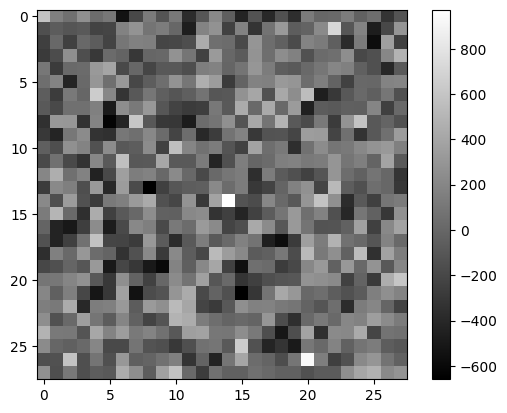

In [79]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

### changing stochasticity (i.e. DDPM vs DDIM)

we can change how much noise we add back into the image


In [80]:
def plot_stochasticities(model, scheduler, stochasticities=[0, 0.2, 0.4, 0.6, 0.8, 1.0], ncols=3):
    nrows = len(stochasticities) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))

    for ax, s in zip(axes.flat, stochasticities):
        image = generate_image(model, scheduler, stochasticity=s, n_images=1)
        ax.imshow(image.cpu().detach().squeeze(), cmap='gray')
        ax.set_title(f's={s}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

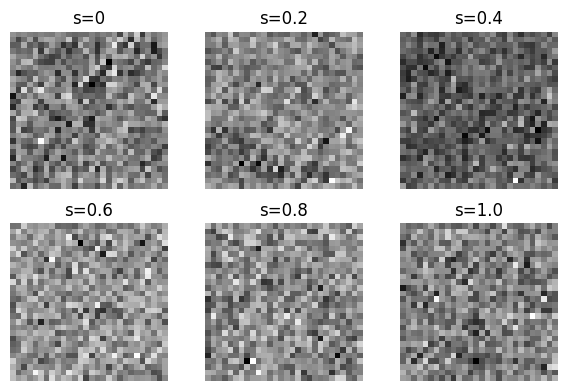

In [81]:
plot_stochasticities(model,scheduler)

### implementing the t embedding

TODO for tomorrow

then, send in


Steps:

time embedding

use cosine based variance schedule (nochol & dhariwal)

conditioning on input numbers
